## Machine Learning Essentials Exercise 1
### 1 Exploring the Data

In [97]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Images size: (1797, 8, 8)


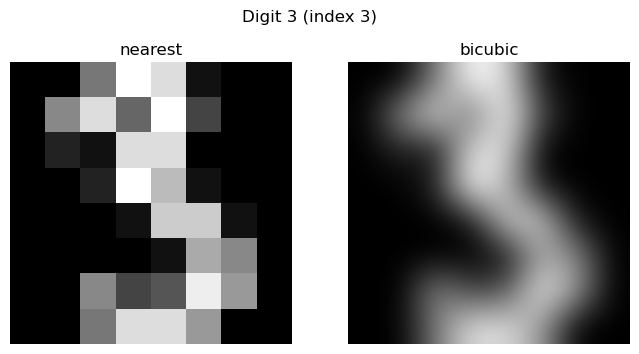

In [72]:
# load the dataset
digits = load_digits()

print(digits.keys())

# extracts data, images, target, target_names
data = digits['data']
images = digits['images']
target = digits['target']
target_names = digits['target_names']

# size of the images
images_size = images.shape

print(f'Images size: {images_size}')

# visualize one image of a 3
# find an idx where target == 3
digit = 3
idx = np.where(target == digit)[0][0] # returns the first index where target is matched
img = images[idx]

# check if img is a 2-D array
assert 2 == len(img.shape), 'The image is not a 2-D array'

# plot with the two interpolation methods('nearest' and 'bicubic')
plt.figure(figsize=(8, 4))
plt.gray()

plt.subplot(1, 2, 1)
plt.imshow(img, interpolation='nearest')
plt.title('nearest')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img, interpolation='bicubic')
plt.title('bicubic')
plt.axis('off')

plt.suptitle(f'Digit {digit} (index {idx})')
plt.show()

# filter the dataset for '3' and '9'
mask = np.isin(target, [3, 9])

data_39 = data[mask]
images_39 = images[mask]
target_39 = target[mask]

# split the filtered dataset into training set and testing set
X_train, X_test, y_train, y_test, images_train, images_test = train_test_split(
    data_39,
    target_39,
    images_39,
    test_size=0.4,
    random_state=0,
    stratify=target_39
)


### 2 Hand-crafted classifier

#### 2.1 Feature Construction

In [73]:
def features2d(X_train, y_train):
    # select the images that are 3 and 9
    mask3 = (y_train == 3)
    mask9 = (y_train == 9)

    img3s = X_train[mask3]
    img9s = X_train[mask9]

    if len(img3s) == 0 or len(img9s) == 0:
        raise ValueError("Training split must contain both classes 3 and 9.")

    # find the average of each pixel across all images
    avg_img3s = img3s.mean(axis=0)
    avg_img9s = img9s.mean(axis=0)

    # calculate the difference
    diff = np.abs(avg_img3s - avg_img9s)

    # find the two pixels position (indices) with biggest difference
    best_pixels_idx = np.argsort(diff)[::-1] # sort from biggest to smallest
    best_idx1 = best_pixels_idx[0]
    best_idx2 = best_pixels_idx[1]

    f1 = X_train[:, best_idx1]
    f2 = X_train[:, best_idx2]

    features = np.column_stack([f1, f2])
    
    return features
    
# build 2D features for the training and test sets.
training_features = features2d(X_train, y_train)
test_features = features2d(X_test, y_test)

#### 2.2 Scatter plot

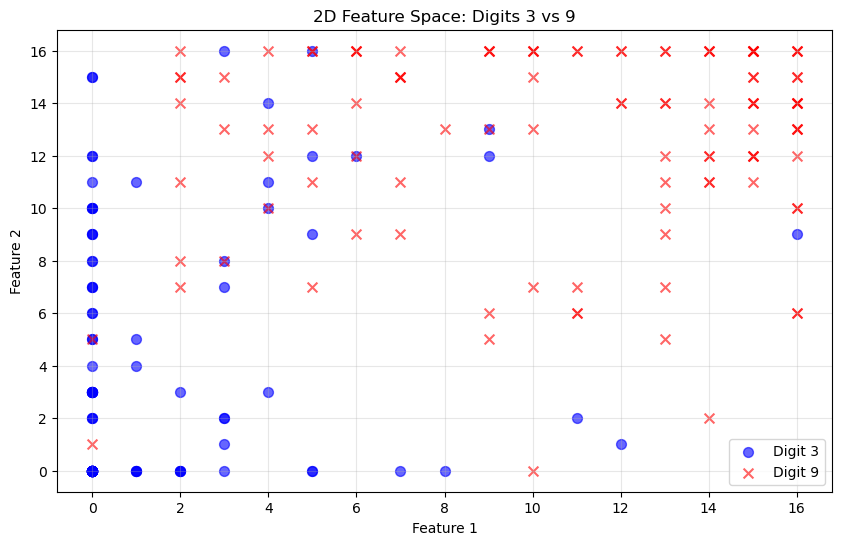

In [10]:
# Scatterplot of the 2D features
plt.figure(figsize=(10, 6))

# separate features by class
mask3 = (y_train == 3)
mask9 = (y_train == 9)

plt.scatter(training_features[mask3, 0], training_features[mask3, 1], 
            label='Digit 3', alpha=0.6, s=50, marker='o', color='blue')
plt.scatter(training_features[mask9, 0], training_features[mask9, 1], 
            label='Digit 9', alpha=0.6, s=50, marker='x', color='red')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Feature Space: Digits 3 vs 9')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### 2.3 Decision rule

In [82]:
def nearest_mean(training_features, training_labels,  test_features):
    # find  the mean for 3 and 9
    mean_3 = training_features[training_labels == -1].mean(axis=0)
    mean_9 = training_features[training_labels == 1].mean(axis=0)

    # for each test points, check which mean is closer
    predicted_labels = []

    for point in test_features:
        dist_to_3 = np.linalg.norm(point - mean_3)
        dist_to_9 = np.linalg.norm(point - mean_9)

        if (dist_to_3 < dist_to_9):
            predicted_labels.append(-1)  # closer to 3 so predict 3
        else:
            predicted_labels.append(1)  # closer to 9 so predict 9

    return np.array(predicted_labels)

# Use -1 for digit 3 and 1 for digit 9 in all later tasks.
y_train_binary = np.where(y_train == 3, -1, 1)
y_test_binary = np.where(y_test == 3, -1, 1)

# Predict labels using the nearest-mean rule.
predicted_train_labels = nearest_mean(training_features, y_train_binary, training_features)
predicted_test_labels = nearest_mean(training_features, y_train_binary, test_features)

def compute_error(predicted_labels, true_labels):
    wrong = np.sum(true_labels != predicted_labels)  # count mistakes
    total = len(true_labels)
    return wrong / total

training_error = compute_error(predicted_train_labels, y_train_binary)
test_error = compute_error(predicted_test_labels, y_test_binary)
print('Training error:', training_error)
print('Test error:', test_error)

def custom_classifier(test_features, beta, b):
    result = test_features @ beta + b
    return np.sign(result)

if (test_error > 0.1):
    # Compute beta as the difference in class means
    mean_3 = training_features[y_train_binary == -1].mean(axis=0)
    mean_9 = training_features[y_train_binary == 1].mean(axis=0)
    
    beta = mean_9 - mean_3 
    b = -79
    
    # Test the custom classifier
    predicted_test_labels = custom_classifier(test_features, beta, b)
    test_error = compute_error(predicted_test_labels, y_test_binary)
    print('Test error with custom classifier:', test_error)


Training error: 0.0967741935483871
Test error: 0.1095890410958904
Test error with custom classifier: 0.10273972602739725


#### 2.4 Visualize the decision regions

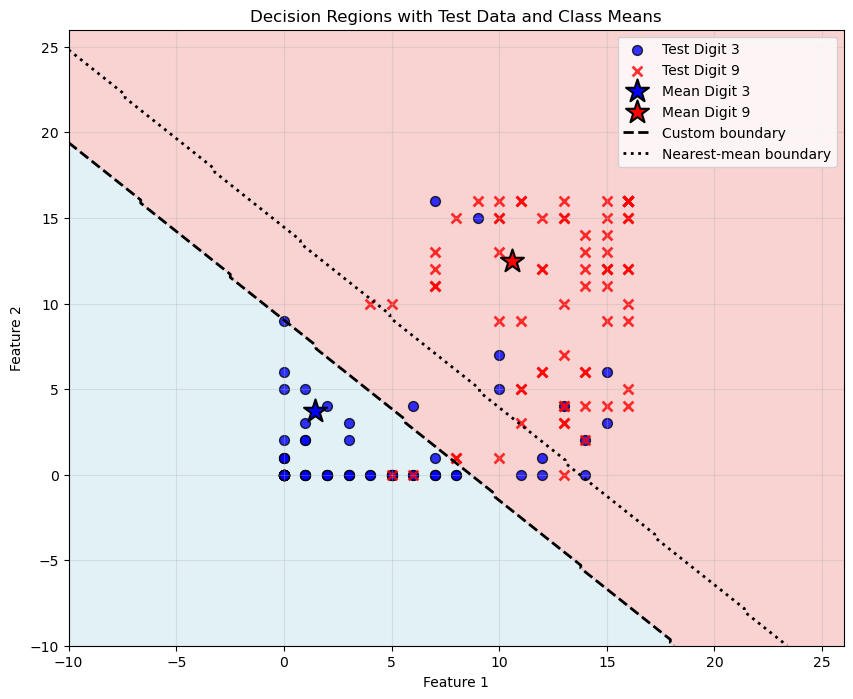

In [69]:
# create a 200x200 grid covering the feature space
grid_size = 200

# find bounds with some padding
min_f1 = training_features[:, 0].min() - 10
max_f1 = training_features[:, 0].max() + 10
min_f2 = training_features[:, 1].min() - 10
max_f2 = training_features[:, 1].max() + 10

# create the grid with the grid_size 200
f1_vals = np.linspace(min_f1, max_f1, grid_size)
f2_vals = np.linspace(min_f2, max_f2, grid_size)
F1, F2 = np.meshgrid(f1_vals, f2_vals)

# flatten grid into feature coordinates
grid_features = np.column_stack([F1.ravel(), F2.ravel()])

# Predict using both classifiers for the grid
Z_custom = custom_classifier(grid_features, beta, b).reshape(F1.shape)
Z_nearest = nearest_mean(training_features, y_train_binary, grid_features).reshape(F1.shape)

# plot decision regions
plt.figure(figsize=(10, 8))
plt.contourf(F1, F2, Z_custom, levels=[-1, 0, 1], colors=['lightblue', 'lightcoral'], alpha=0.35)

# plot decision boundary lines for both classifiers
cs_custom = plt.contour(F1, F2, Z_custom, levels=[0], colors='k', linewidths=2, linestyles='--')
cs_nearest = plt.contour(F1, F2, Z_nearest, levels=[0], colors='k', linewidths=2, linestyles=':')

# overlay test data
mask3_test = (y_test_binary == -1)
mask9_test = (y_test_binary == 1)
sc3 = plt.scatter(test_features[mask3_test, 0], test_features[mask3_test, 1], 
            label='Test Digit 3', alpha=0.8, s=50, marker='o', color='blue', edgecolors='black')
sc9 = plt.scatter(test_features[mask9_test, 0], test_features[mask9_test, 1], 
            label='Test Digit 9', alpha=0.8, s=50, marker='x', color='red', linewidths=2)

# Plot class means
mean_3 = training_features[y_train_binary == -1].mean(axis=0)
mean_9 = training_features[y_train_binary == 1].mean(axis=0)
mean3_sc = plt.scatter(mean_3[0], mean_3[1], marker='*', s=300, color='blue', 
            edgecolors='black', linewidth=1.5, label='Mean Digit 3', zorder=5)
mean9_sc = plt.scatter(mean_9[0], mean_9[1], marker='*', s=300, color='red', 
            edgecolors='black', linewidth=1.5, label='Mean Digit 9', zorder=5)

# add proxies for the two decision-boundary styles so they appear in the legend
custom_line = Line2D([0], [0], color='k', linestyle='--', linewidth=2)
nearest_line = Line2D([0], [0], color='k', linestyle=':', linewidth=2)

# build legend
handles, labels = plt.gca().get_legend_handles_labels()
handles.extend([custom_line, nearest_line])
labels.extend(['Custom boundary', 'Nearest-mean boundary'])
plt.legend(handles, labels, loc='best')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Regions with Test Data and Class Means')
plt.grid(True, alpha=0.3)
plt.xlim(min_f1, max_f1)
plt.ylim(min_f2, max_f2)
plt.show()


### 3 LDA
#### 3.1 Implement LDA training

In [75]:
def fit_lda(training_features, training_labels):
    # split classes
    x_neg = training_features[training_labels == -1]
    x_pos = training_features[training_labels == 1]

    n_neg = x_neg.shape[0]
    n_pos = x_pos.shape[0]
    n_total = training_features.shape[0]

    # class means
    mu_neg = x_neg.mean(axis=0)
    mu_pos = x_pos.mean(axis=0)
    mu = np.vstack([mu_neg, mu_pos])

    # shared covariance from lecture formula
    d_neg = x_neg - mu_neg
    d_pos = x_pos - mu_pos
    covmat = (d_neg.T @ d_neg + d_pos.T @ d_pos) / n_total

    # class priors
    p = np.array([n_neg / n_total, n_pos / n_total])

    return mu, covmat, p


# 2d features from task 2
X2_train = training_features
X2_test = test_features

# full 64-d features with dead pixels removed
pixel_var = np.var(data_39, axis=0)
live_mask = pixel_var >= 0.001
Xfull_train = X_train[:, live_mask]
Xfull_test = X_test[:, live_mask]

# fit lda on both feature sets
mu_2d, cov_2d, p_2d = fit_lda(X2_train, y_train_binary)
mu_full, cov_full, p_full = fit_lda(Xfull_train, y_train_binary)

print('2d mu shape:', mu_2d.shape)
print('2d cov shape:', cov_2d.shape)
print('2d priors:', p_2d)
print('full mu shape:', mu_full.shape)
print('full cov shape:', cov_full.shape)
print('full priors:', p_full)
print('number of active pixels:', live_mask.sum(), 'out of 64')


2d mu shape: (2, 2)
2d cov shape: (2, 2)
2d priors: [0.50230415 0.49769585]
full mu shape: (2, 56)
full cov shape: (56, 56)
full priors: [0.50230415 0.49769585]
number of active pixels: 56 out of 64


#### 3.2 Implement LDA prediction

In [79]:
def predict_lda(mu, covmat, p, test_features):
    # beta and b from the decision rule in the task
    mu_neg = mu[0]
    mu_pos = mu[1]

    # add tiny diagonal regularization for numerical stability
    eps = 1e-6
    cov_stable = covmat + eps * np.eye(covmat.shape[0])

    inv_cov = np.linalg.inv(cov_stable)
    beta = inv_cov @ (mu_pos - mu_neg)
    b = -0.5 * ((mu_pos + mu_neg) @ beta) + np.log(p[1] / p[0])

    scores = test_features @ beta + b
    predicted_labels = np.where(scores >= 0, 1, -1)
    return predicted_labels


# evaluate on 2d features
pred_2d_train = predict_lda(mu_2d, cov_2d, p_2d, X2_train)
pred_2d_test = predict_lda(mu_2d, cov_2d, p_2d, X2_test)
err_2d_train = np.mean(pred_2d_train != y_train_binary)
err_2d_test = np.mean(pred_2d_test != y_test_binary)

# evaluate on full active-pixel features
pred_full_train = predict_lda(mu_full, cov_full, p_full, Xfull_train)
pred_full_test = predict_lda(mu_full, cov_full, p_full, Xfull_test)
err_full_train = np.mean(pred_full_train != y_train_binary)
err_full_test = np.mean(pred_full_test != y_test_binary)

print('2d lda train error:', err_2d_train)
print('2d lda test error :', err_2d_test)
print('full lda train error:', err_full_train)
print('full lda test error :', err_full_test)


2d lda train error: 0.09216589861751152
2d lda test error : 0.1095890410958904
full lda train error: 0.0
full lda test error : 0.02054794520547945


#### 3.3 Visualization

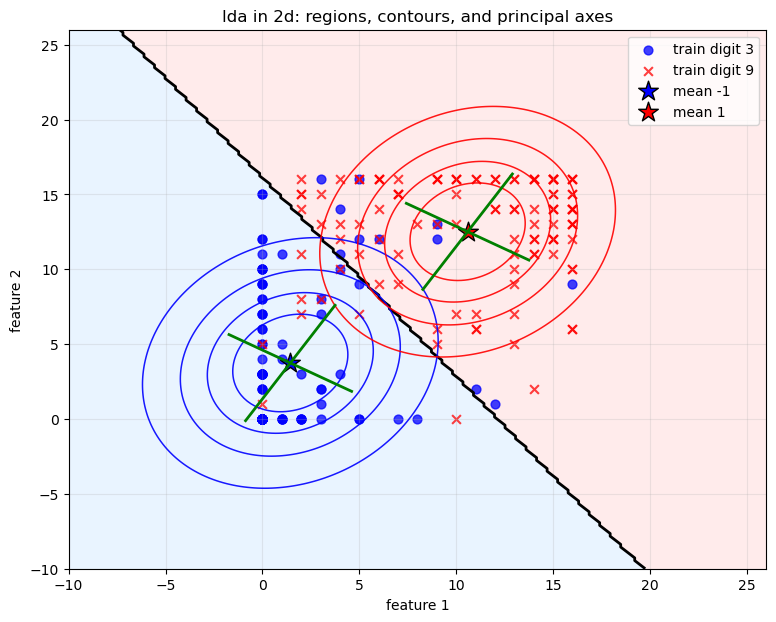

2d train error: 0.09216589861751152
2d test error : 0.1095890410958904
train quality: good separation on training data
test quality: generalization looks reasonable on test data


In [96]:
# build a 200x200 grid in 2d feature space
pad = 10
x1_min, x1_max = X2_train[:, 0].min() - pad, X2_train[:, 0].max() + pad
x2_min, x2_max = X2_train[:, 1].min() - pad, X2_train[:, 1].max() + pad

x1 = np.linspace(x1_min, x1_max, 200)
x2 = np.linspace(x2_min, x2_max, 200)
G1, G2 = np.meshgrid(x1, x2)
Xg = np.column_stack([G1.ravel(), G2.ravel()])

# lda decision regions on the grid
pred_grid = predict_lda(mu_2d, cov_2d, p_2d, Xg).reshape(G1.shape)

# gaussian contour helper with shared covariance
def gaussian_density_grid(X, mean, cov):
    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)
    diff = X - mean
    q = np.einsum('ij,jk,ik->i', diff, inv_cov, diff)
    norm = 1.0 / (2 * np.pi * np.sqrt(det_cov))
    return norm * np.exp(-0.5 * q)

# class isocontours
Z_neg = gaussian_density_grid(Xg, mu_2d[0], cov_2d).reshape(G1.shape)
Z_pos = gaussian_density_grid(Xg, mu_2d[1], cov_2d).reshape(G1.shape)

# eigen decomposition for principal axes
eigvals, eigvecs = np.linalg.eig(cov_2d)
stds = np.sqrt(np.maximum(eigvals, 0))

plt.figure(figsize=(9, 7))

# decision regions and boundary
plt.contourf(G1, G2, pred_grid, levels=[-1, 0, 1], colors=['#cfe8ff', '#ffd3d3'], alpha=0.45)
plt.contour(G1, G2, pred_grid, levels=[0], colors='k', linewidths=2)

# overlay training data
m3 = y_train_binary == -1
m9 = y_train_binary == 1
plt.scatter(X2_train[m3, 0], X2_train[m3, 1], color='blue', marker='o', s=40, alpha=0.75, label='train digit 3')
plt.scatter(X2_train[m9, 0], X2_train[m9, 1], color='red', marker='x', s=40, alpha=0.75, label='train digit 9')

# means
plt.scatter(mu_2d[0, 0], mu_2d[0, 1], color='blue', marker='*', s=220, edgecolors='black', label='mean -1')
plt.scatter(mu_2d[1, 0], mu_2d[1, 1], color='red', marker='*', s=220, edgecolors='black', label='mean 1')

# gaussian isocontours
levels_neg = np.linspace(Z_neg.max() * 0.15, Z_neg.max() * 0.75, 4)
levels_pos = np.linspace(Z_pos.max() * 0.15, Z_pos.max() * 0.75, 4)
plt.contour(G1, G2, Z_neg, levels=levels_neg, colors='blue', linewidths=1.1, alpha=0.9)
plt.contour(G1, G2, Z_pos, levels=levels_pos, colors='red', linewidths=1.1, alpha=0.9)

# principal axes centered at each class mean
for mean in [mu_2d[0], mu_2d[1]]:
    for k in range(2):
        v = eigvecs[:, k].real
        s = stds[k].real
        p1 = mean - s * v
        p2 = mean + s * v
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='green', linewidth=2)

plt.title('lda in 2d: regions, contours, and principal axes')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend(loc='best')
plt.grid(alpha=0.25)
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.show()

# short quality comments for train and test
print('2d train error:', err_2d_train)
print('2d test error :', err_2d_test)
if err_2d_train < 0.15:
    print('train quality: good separation on training data')
else:
    print('train quality: overlap is still visible on training data')

if err_2d_test < 0.20:
    print('test quality: generalization looks reasonable on test data')
else:
    print('test quality: generalization is weak, there is noticeable overlap')


#### 3.4 Quantitative performance evaluation

our lda 10-fold errors: [0.     0.027  0.027  0.     0.     0.0278 0.0278 0.     0.     0.    ]
our lda mean cv error: 0.01096096096096096
our lda std cv error : 0.013426479823488383
sklearn 10-fold errors: [0.     0.027  0.027  0.     0.     0.0278 0.0278 0.     0.     0.    ]
sklearn mean cv error: 0.01096096096096096
sklearn std cv error : 0.013426479823488383


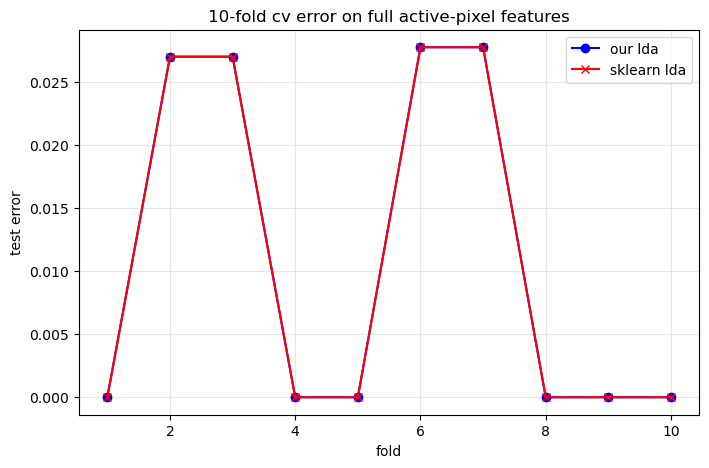

In [98]:
# full dataset (digits 3 and 9 only) with dead pixels removed
X_all = data_39[:, live_mask]
y_all = np.where(target_39 == 3, -1, 1)

# 10-fold cross validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

custom_cv_errors = []
sklearn_cv_errors = []

for train_idx, test_idx in skf.split(X_all, y_all):
    Xtr, Xte = X_all[train_idx], X_all[test_idx]
    ytr, yte = y_all[train_idx], y_all[test_idx]

    # our lda
    mu_cv, cov_cv, p_cv = fit_lda(Xtr, ytr)
    yhat_cv = predict_lda(mu_cv, cov_cv, p_cv, Xte)
    custom_cv_errors.append(np.mean(yhat_cv != yte))

    # sklearn lda
    sk_lda = LinearDiscriminantAnalysis(solver='svd')
    sk_lda.fit(Xtr, ytr)
    yhat_sk = sk_lda.predict(Xte)
    sklearn_cv_errors.append(np.mean(yhat_sk != yte))

custom_cv_errors = np.array(custom_cv_errors)
sklearn_cv_errors = np.array(sklearn_cv_errors)

print('our lda 10-fold errors:', np.round(custom_cv_errors, 4))
print('our lda mean cv error:', custom_cv_errors.mean())
print('our lda std cv error :', custom_cv_errors.std())
print('sklearn 10-fold errors:', np.round(sklearn_cv_errors, 4))
print('sklearn mean cv error:', sklearn_cv_errors.mean())
print('sklearn std cv error :', sklearn_cv_errors.std())

# simple comparison plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), custom_cv_errors, marker='o', label='our lda', color='blue')
plt.plot(range(1, 11), sklearn_cv_errors, marker='x', label='sklearn lda', color='red')
plt.xlabel('fold')
plt.ylabel('test error')
plt.title('10-fold cv error on full active-pixel features')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### 4 SVM